# Recession Prediction Project
## Exploratory Data Analysis and Preprocessing

This notebook focuses on loading, cleaning, and exploring economic data to understand the factors associated with US Recessions. The goal is to prepare a clean dataset for machine learning models.

### Project Workflow:
1. **Data Loading**: Import the economic indicators and recession labels.
2. **Data Cleaning**: Handle date formats, merge datasets, and manage missing values.
3. **Exploratory Data Analysis (EDA)**: Visualize trends, correlations, and distributions.
4. **Visualizations**: Plot key indicators with recession periods highlighted.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
%matplotlib inline

### 2. Data Loading
We load two datasets:
- `final_combined_dataset.csv`: Contains 100+ economic indicators.
- `USREC.csv`: Contains the recession labels (NBER based).

In [2]:
# Load datasets
df_indicators = pd.read_csv('final_combined_dataset.csv')
df_recession = pd.read_csv('USREC.csv')

print(f"Indicators dataset shape: {df_indicators.shape}")
print(f"Recession labels shape: {df_recession.shape}")

Indicators dataset shape: (87900, 145)
Recession labels shape: (2056, 2)


### 3. Data Cleaning and Preprocessing

The indicators dataset contains a meta-data row ('Transform') at index 0 and multiple versions of data snapshots. We need to filter for unique dates and merge with labels.

In [3]:
# 3.1 Remove the 'Transform' meta-data row
df_indicators = df_indicators[df_indicators['sasdate'] != 'Transform:']

# 3.2 Convert date columns to datetime
df_indicators['sasdate'] = pd.to_datetime(df_indicators['sasdate'])
df_recession['observation_date'] = pd.to_datetime(df_recession['observation_date'])

# 3.3 Drop duplicates to get a unique time series (keeping the latest observation for each date)
df_indicators = df_indicators.sort_values('sasdate').drop_duplicates(subset='sasdate', keep='last')

# 3.4 Merge the datasets on date
df = pd.merge(df_indicators, df_recession, left_on='sasdate', right_on='observation_date', how='inner')

# 3.5 Drop redundant columns and columns with all null values
df.drop(columns=['observation_date', 'source_file'], inplace=True, errors='ignore')
df.dropna(axis=1, how='all', inplace=True)

# 3.6 Fill remaining missing values using forward fill (common for time series)
df.fillna(method='ffill', inplace=True)

df.set_index('sasdate', inplace=True)
print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (791, 144)


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,NAPMSDI,NAPMII,PPIFGS,PPIFCG,PPIITM,PPICRM,NAPMPRI,CUUR0000SAD,CUUR0000SA0L2,USREC
sasdate,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,276676.8154,18235.77392,21.9665,23.3891,22.2688,31.7011,19.0149,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1959-02-01,2446.902,2297.0,17.482,294429.5453,18369.56308,23.0681,23.7747,22.3827,32.6455,22.1036,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1959-03-01,2314.456,2176.2,18.555,256866.3717,18521.70306,23.5041,24.0760,22.6689,32.6782,22.6040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1959-04-01,2328.668,2190.7,18.488,262043.8285,18533.11061,24.0048,24.4237,23.0011,33.1937,22.7487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1959-05-01,2498.026,2350.4,17.765,301364.3249,18679.66354,23.6673,24.4077,23.1408,32.4565,19.6396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


### 4. Exploratory Data Analysis (EDA)

#### 4.1 Target Variable Distribution
Let's see how many months are classified as 'Recession' (1) vs 'Non-Recession' (0).

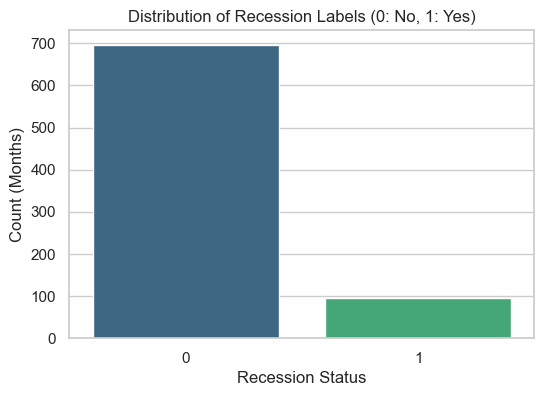

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='USREC', data=df, palette='viridis')
plt.title('Distribution of Recession Labels (0: No, 1: Yes)')
plt.xlabel('Recession Status')
plt.ylabel('Count (Months)')
plt.show()

#### 4.2 Correlation Analysis
We check which indicators correlate most strongly with the recession label.

In [5]:
correlations = df.corr()['USREC'].sort_values(ascending=False)

print("Top 10 Positively Correlated Indicators:")
print(correlations.head(11)[1:]) # Exclude USREC itself

print("\nTop 10 Negatively Correlated Indicators:")
print(correlations.tail(10))

Top 10 Positively Correlated Indicators:
VXOCLSx          0.472588
S&P div yield    0.315195
VIXCLSx          0.276521
BAA              0.273462
CLAIMSx          0.262200
ISRATIOx         0.255753
CP3Mx            0.236751
AAA              0.231373
FEDFUNDS         0.227735
UEMPLT5          0.224095
Name: USREC, dtype: float64

Top 10 Negatively Correlated Indicators:
PERMIT          -0.335030
NAPMEI          -0.354740
AWOTMAN         -0.364791
TB3SMFFM        -0.367261
NAPM            -0.376227
UMCSENTx        -0.402595
NAPMNOI         -0.433692
NAPMPI          -0.442071
CES0600000007   -0.455373
AWHMAN          -0.470747
Name: USREC, dtype: float64


### 5. Visualizations

#### 5.1 Key Economic Indicators over Time
Recessions are shaded in gray to see how indicators like Unemployment and Industrial Production behave.

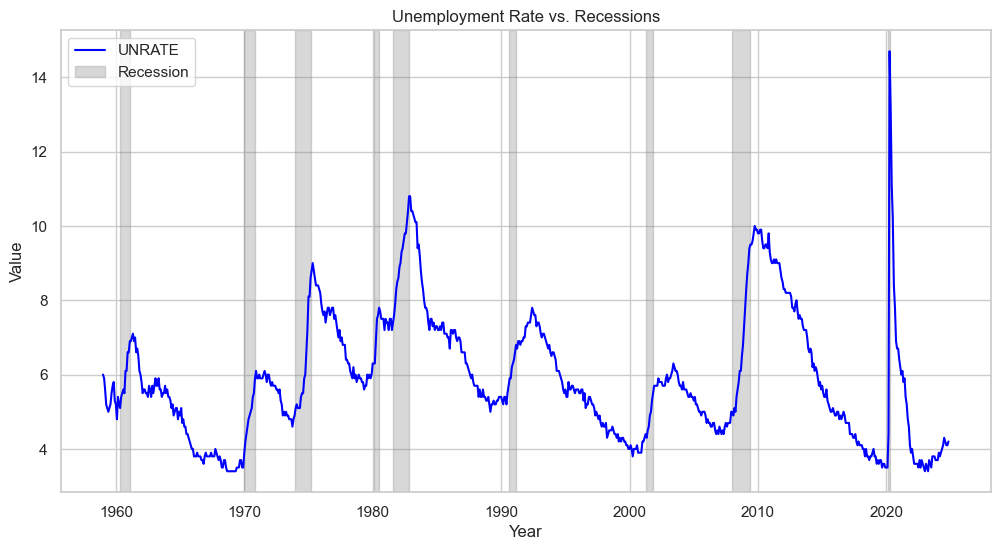

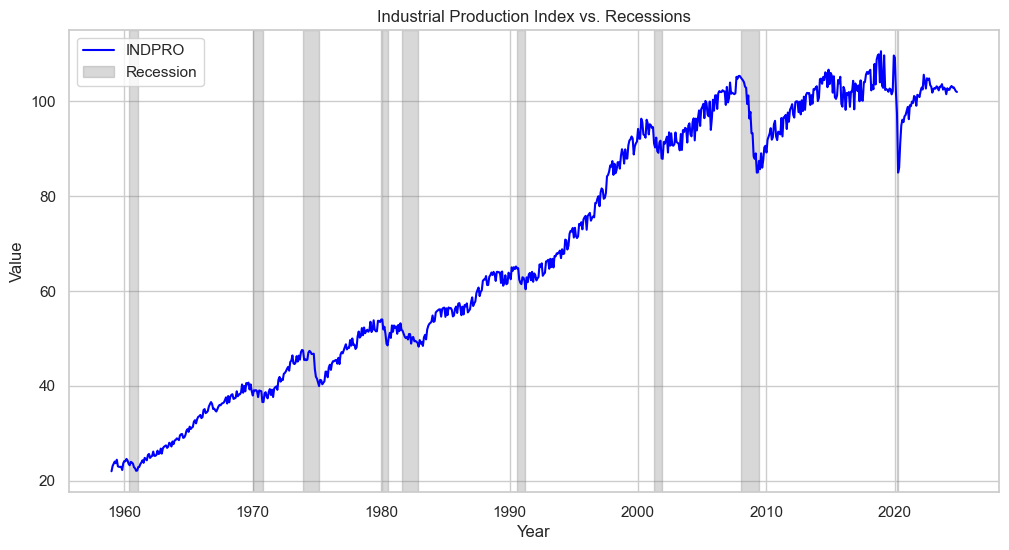

In [6]:
def plot_indicator_with_recession(data, column, title):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data[column], color='blue', label=column)
    plt.fill_between(data.index, 0, 1, where=data['USREC'] == 1, 
                     color='gray', alpha=0.3, transform=plt.gca().get_xaxis_transform(), label='Recession')
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# Plotting Unemployment Rate (UNRATE)
plot_indicator_with_recession(df, 'UNRATE', 'Unemployment Rate vs. Recessions')

# Plotting Industrial Production (INDPRO)
plot_indicator_with_recession(df, 'INDPRO', 'Industrial Production Index vs. Recessions')

#### 5.2 Heatmap of Correlations
Visualizing the relationships between a subset of highly correlated variables.

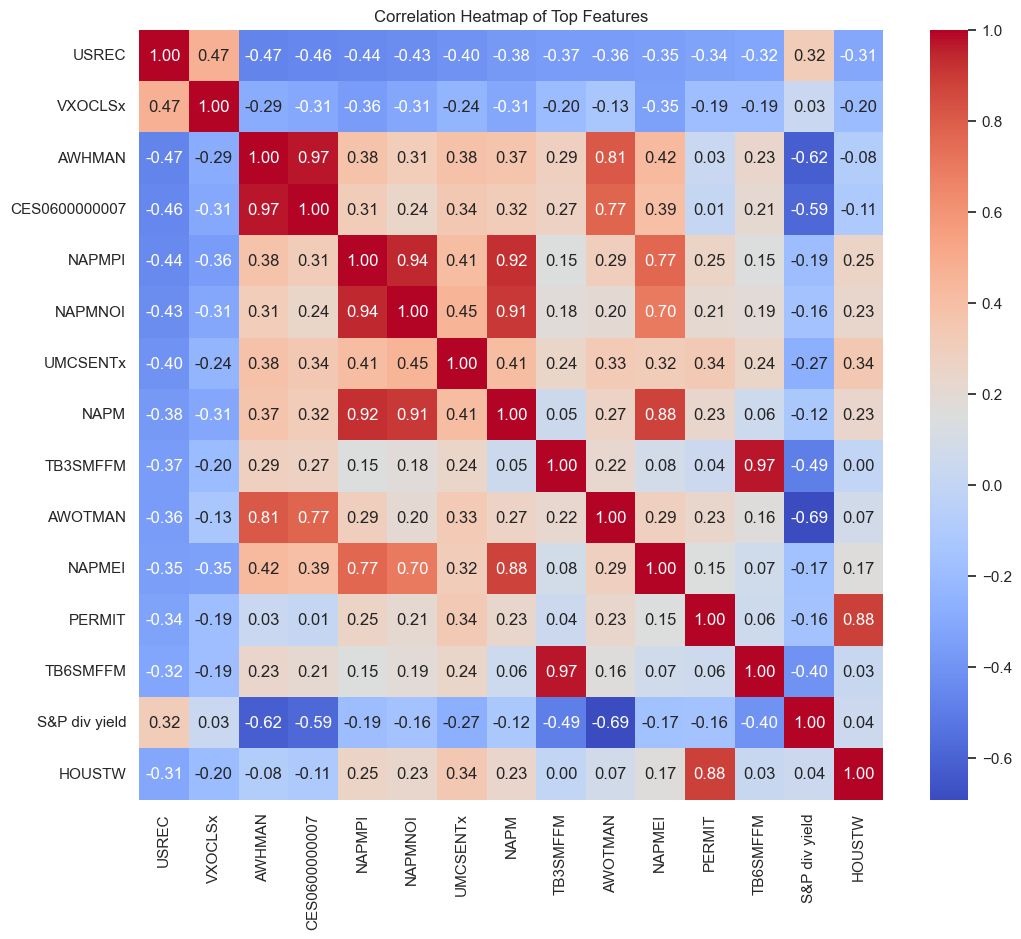

In [7]:
top_features = correlations.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top Features')
plt.show()

### 6. Conclusion
The data is now cleaned and merged. We observed:
- High correlation between unemployment, industrial production, and recessions.
- The dataset is imbalanced (fewer recession months than expansion months), which should be addressed during ML model training (e.g., using SMOTE or specific loss functions).
- Next steps include feature scaling and time-series split for model evaluation.